Buscando dados da malha municipal no IBGE...
Mapa 'mapa_ibge_sirgas.png' gerado com sucesso!


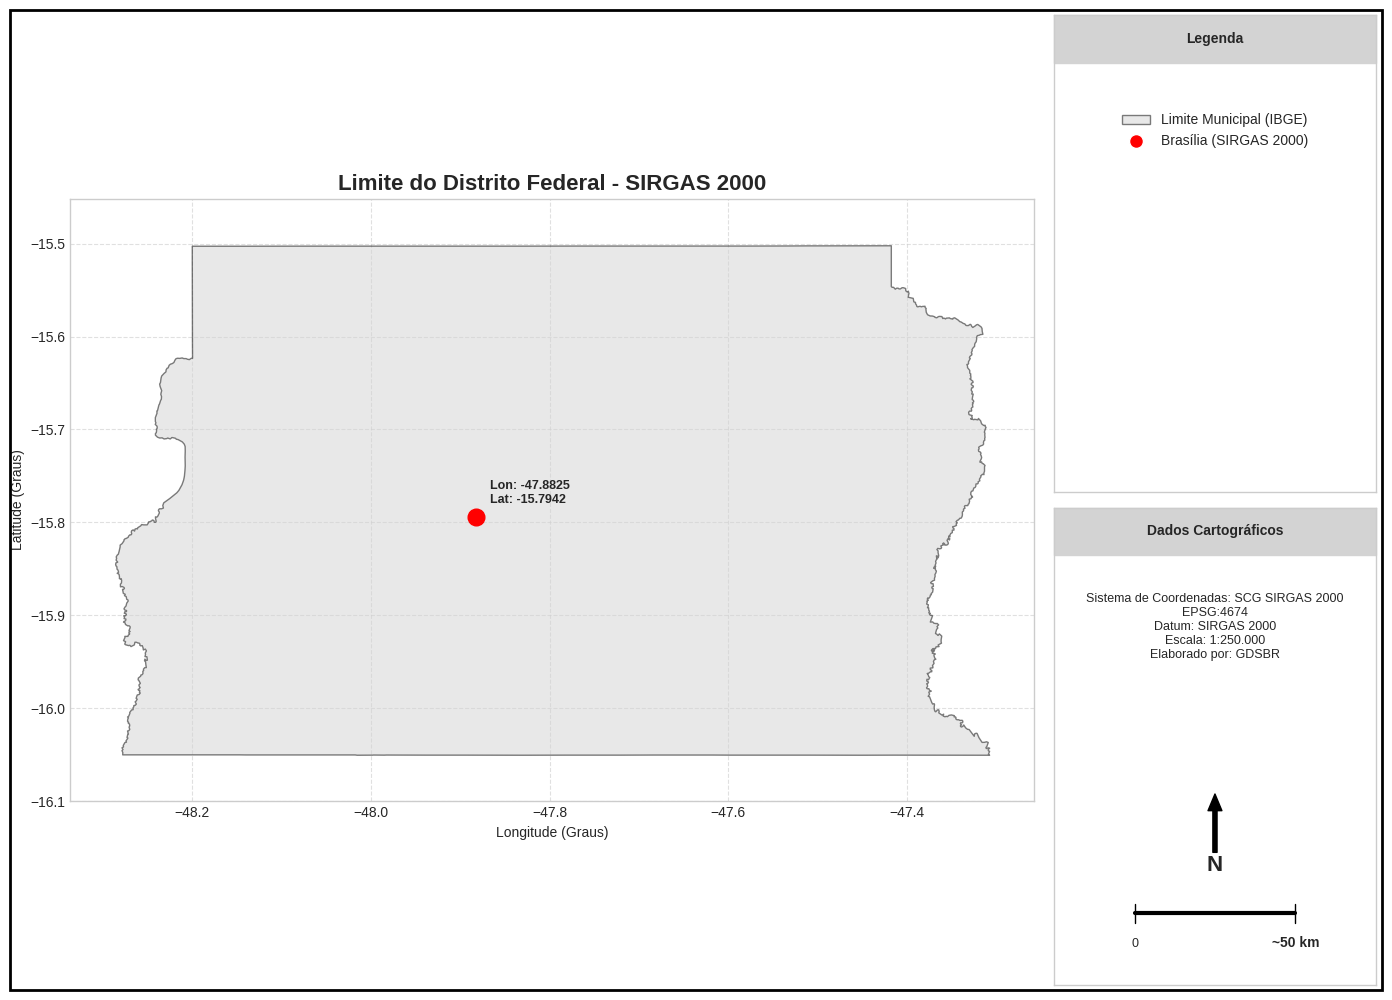

In [3]:
# =============================================================================
# MAPA BASE - Distrito Federal (Brasília)
# Projeto: GDS_BR | Geo Data Science Brasil
# Descrição: Script para gerar um mapa cartográfico do Distrito Federal com
#            dados oficiais do IBGE, usando o sistema SIRGAS 2000 (EPSG:4674).
# =============================================================================


# --- SEÇÃO 1: IMPORTAÇÃO DAS BIBLIOTECAS ---
# Antes de usar qualquer ferramenta, precisamos "importar" (carregar) as
# bibliotecas necessárias. Pense nelas como caixas de ferramentas especializadas.

import matplotlib.pyplot as plt                # Ferramenta principal para desenhar gráficos e mapas
from matplotlib.lines import Line2D            # Ferramenta para criar linhas personalizadas (usada na legenda)
from matplotlib.patches import Patch, Rectangle # 'Patch': áreas coloridas na legenda | 'Rectangle': desenhar retângulos
import geopandas as gpd                        # Ferramenta para trabalhar com dados geográficos (mapas, polígonos...)
import requests                                # Ferramenta para fazer requisições à internet (baixar dados de APIs)
import io                                      # Ferramenta para tratar dados em memória como se fossem um arquivo
from shapely.geometry import Point             # Ferramenta para criar geometrias (Ponto, Linha, Polígono)
from pyproj import Transformer                 # Ferramenta para converter coordenadas entre diferentes projeções

# --- SEÇÃO 2: CONFIGURAÇÃO DO ESTILO VISUAL ---
# Aplicamos um estilo visual ao gráfico. O 'try/except' é uma forma segura de
# tentar algo e, caso dê erro, executar uma alternativa.

try:
    plt.style.use('seaborn-v0_8-whitegrid')  # Tenta usar o estilo seaborn (fundo branco com grade)
except Exception:
    plt.style.use('ggplot')                  # Se o estilo acima não existir, usa o estilo 'ggplot' como alternativa

# --- SEÇÃO 3: DADOS GEOGRÁFICOS E PROJEÇÃO ---
# Aqui definimos o ponto central de Brasília e o convertemos para o sistema
# de coordenadas oficial do Brasil: SIRGAS 2000 (EPSG:4674).

# Cria um objeto que sabe converter coordenadas do GPS (EPSG:4326) para SIRGAS 2000 (EPSG:4674)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:4674", always_xy=True)

lon, lat = -47.8825, -15.7942  # Define a longitude e latitude de Brasília (obtidas do GPS/Google Maps)
x, y = transformer.transform(lon, lat)  # Converte as coordenadas GPS para o sistema SIRGAS 2000

ponto_brasilia = Point(x, y)  # Cria um objeto geométrico do tipo "Ponto" com as coordenadas convertidas

# --- SEÇÃO 4: BUSCANDO DADOS GEOGRÁFICOS DO IBGE ---
# O IBGE disponibiliza as malhas (polígonos) dos municípios via API.
# Aqui baixamos o polígono do Distrito Federal diretamente da internet.

# Endereço da API do IBGE para o município de Brasília (ID 5300108), formato GeoJSON, qualidade máxima
url_ibge = "https://servicodados.ibge.gov.br/api/v4/malhas/municipios/5300108?formato=application/vnd.geo+json&qualidade=maxima"

print("Buscando dados da malha municipal no IBGE...")  # Avisa o usuário que o download está começando

response = requests.get(url_ibge)  # Faz a requisição (download) para a URL do IBGE e armazena a resposta

# Lê o conteúdo baixado (em bytes) e o converte em um GeoDataFrame (tabela com dados geográficos)
gdf_municipio = gpd.read_file(io.BytesIO(response.content))

# Converte o sistema de coordenadas da malha para SIRGAS 2000, para combinar com o ponto de Brasília
gdf_municipio = gdf_municipio.to_crs("EPSG:4674")

# --- SEÇÃO 5: DEFINIÇÃO DO LAYOUT DO MAPA (MOSAICO) ---
# Usamos um "mosaico" para organizar o espaço do mapa em painéis.
# O painel 'mapa' ocupa as duas linhas da esquerda.
# O painel 'legenda' fica no topo direito e 'info' na parte inferior direita.

layout = [
    ['mapa', 'legenda'],  # Linha 1: mapa à esquerda, legenda à direita
    ['mapa', 'info']      # Linha 2: mapa continua à esquerda, info cartográfica à direita
]

# Cria a figura e os eixos (painéis) de acordo com o layout acima
# figsize=(14,10): tamanho da figura em polegadas | width_ratios=[3,1]: a coluna do mapa é 3x mais larga
fig, axs = plt.subplot_mosaic(layout, figsize=(14, 10), width_ratios=[3, 1])

ax_mapa = axs['mapa']       # Atalho para o painel principal do mapa
ax_info = axs['info']       # Atalho para o painel de informações cartográficas
ax_legenda = axs['legenda'] # Atalho para o painel de legenda

# --- SEÇÃO 6: PLOTAGEM DO MAPA PRINCIPAL ---

# Desenha a malha municipal (polígono do DF) no eixo do mapa
gdf_municipio.plot(ax=ax_mapa, color='lightgrey', edgecolor='black', alpha=0.5, label='Distrito Federal')

# Desenha o ponto de Brasília como um marcador circular vermelho
ax_mapa.plot(
    ponto_brasilia.x,       # Coordenada X (longitude em SIRGAS 2000) do ponto
    ponto_brasilia.y,       # Coordenada Y (latitude em SIRGAS 2000) do ponto
    marker='o',             # Formato do marcador: círculo
    color='red',            # Cor do marcador: vermelho
    markersize=12,          # Tamanho do marcador
    linestyle='None',       # Sem linha conectando os marcadores
    label='Brasília (SIRGAS 2000)'  # Rótulo que aparecerá na legenda
)

# Adiciona uma anotação de texto com as coordenadas ao lado do ponto
ax_mapa.annotate(
    f'Lon: {ponto_brasilia.x:.4f}\nLat: {ponto_brasilia.y:.4f}',  # Texto com 4 casas decimais
    (ponto_brasilia.x, ponto_brasilia.y),                           # Posição do 'alvo' da anotação
    xytext=(10, 10),               # Deslocamento do texto em relação ao ponto (10 pixels para direita e cima)
    textcoords='offset points',    # Informa que o deslocamento é em pontos (pixels)
    fontsize=9,                    # Tamanho da fonte
    fontweight='bold'              # Texto em negrito
)

# Ajusta os limites do eixo do mapa para enquadrar o município com uma pequena margem
minx, miny, maxx, maxy = gdf_municipio.total_bounds  # Obtém os limites geográficos (bounding box) da malha
ax_mapa.set_xlim(minx - 0.05, maxx + 0.05)           # Define o limite horizontal com 0.05 de margem
ax_mapa.set_ylim(miny - 0.05, maxy + 0.05)           # Define o limite vertical com 0.05 de margem

ax_mapa.set_title('Limite do Distrito Federal - SIRGAS 2000', fontsize=16, fontweight='bold')  # Título do painel
ax_mapa.set_xlabel('Longitude (Graus)')   # Rótulo do eixo horizontal
ax_mapa.set_ylabel('Latitude (Graus)')    # Rótulo do eixo vertical
ax_mapa.grid(True, linestyle='--', alpha=0.6)  # Adiciona uma grade tracejada com 60% de opacidade

# --- SEÇÃO 7: PAINEL DE INFORMAÇÕES CARTOGRÁFICAS ---

# Torna visível a borda (spine) ao redor do painel de informações
for spine in ax_info.spines.values():  # Itera sobre cada um dos 4 lados do painel
    spine.set_visible(True)            # Torna o lado visível
    spine.set_linewidth(1)             # Define a espessura da borda como 1pt

ax_info.set_xticks([])  # Remove os marcadores do eixo X (não precisamos de números aqui)
ax_info.set_yticks([])  # Remove os marcadores do eixo Y

# Adiciona um retângulo cinza como cabeçalho (header) no topo do painel
# Rectangle((x_inicio, y_inicio), largura, altura, ...)
# Aqui usamos coordenadas de eixo (0 a 1), então (0, 0.9) é o canto inferior esquerdo do header
ax_info.add_patch(Rectangle(
    (0, 0.9), 1, 0.1,                   # Começa no canto esquerdo, altura 0.9, ocupa toda a largura (1) com altura de 0.1
    transform=ax_info.transAxes,         # Informa que as coordenadas são relativas ao tamanho do eixo
    facecolor='lightgrey',               # Cor de preenchimento: cinza claro
    edgecolor='lightgrey',               # Cor da borda do retângulo: cinza claro (mesma cor para não mostrar borda)
    lw=1,                                # Espessura da borda
    clip_on=False                        # Permite que o retângulo apareça mesmo que ultrapasse os limites do eixo
))

# Adiciona o texto "Dados Cartográficos" centralizado dentro do cabeçalho
ax_info.text(
    0.5, 0.95,                           # Posição X=50% (centro), Y=95% (dentro do header)
    "Dados Cartográficos",               # Texto a ser exibido
    transform=ax_info.transAxes,         # Coordenadas relativas ao eixo
    fontsize=10, fontweight='bold',      # Tamanho e peso da fonte
    ha='center', va='center'            # Alinhamento horizontal e vertical: centralizado
)

# Texto com as informações do sistema de referência e metadados do mapa
texto_carto = (
    "Sistema de Coordenadas: SCG SIRGAS 2000\n"  # \n = quebra de linha
    "EPSG:4674\n"
    "Datum: SIRGAS 2000\n"
    "Escala: 1:250.000\n"
    "Elaborado por: GDSBR"
)
# Exibe o texto de informações cartográficas abaixo do cabeçalho
ax_info.text(0.5, 0.82, texto_carto, transform=ax_info.transAxes, fontsize=9, ha='center', va='top')

# Desenha a seta do símbolo de Norte
# annotate() cria uma anotação com texto e seta
ax_info.annotate(
    'N',                                          # Texto que aparece na ponta da seta (o "N" de Norte)
    xy=(0.5, 0.40),                              # Ponto de destino da seta (onde a seta aponta)
    xytext=(0.5, 0.25),                          # Ponto de origem da seta (onde o texto "N" fica)
    arrowprops=dict(facecolor='black', width=3, headwidth=10),  # Estilo da seta: preta, largura 3, ponta larga 10
    ha='center', va='center',                    # Alinhamento do texto
    fontsize=16, fontweight='bold',              # Tamanho e peso da fonte do "N"
    xycoords=ax_info.transAxes                   # Coordenadas relativas ao eixo
)

# Desenha a escala gráfica (uma linha horizontal com marcadores nas pontas)
ax_info.plot([0.25, 0.75], [0.15, 0.15], transform=ax_info.transAxes, color='black', lw=3)   # Linha principal da escala
ax_info.plot([0.25, 0.25], [0.13, 0.17], transform=ax_info.transAxes, color='black', lw=1)   # Marcador esquerdo
ax_info.plot([0.75, 0.75], [0.13, 0.17], transform=ax_info.transAxes, color='black', lw=1)   # Marcador direito
ax_info.text(0.25, 0.08, "0",       transform=ax_info.transAxes, ha='center', fontsize=9)              # Rótulo "0" na esquerda
ax_info.text(0.75, 0.08, "~50 km",  transform=ax_info.transAxes, ha='center', fontsize=10, fontweight='bold')  # Rótulo "~50km" na direita

# --- SEÇÃO 8: PAINEL DA LEGENDA ---

# Torna visível a borda ao redor do painel de legenda (mesmo padrão do painel de info)
for spine in ax_legenda.spines.values():  # Itera sobre os 4 lados do painel
    spine.set_visible(True)               # Torna o lado visível
    spine.set_linewidth(1)                # Define a espessura da borda

ax_legenda.set_xticks([])  # Remove marcadores do eixo X
ax_legenda.set_yticks([])  # Remove marcadores do eixo Y

# Adiciona o retângulo cinza de cabeçalho para a seção de Legenda (mesma estrutura do painel de info)
ax_legenda.add_patch(Rectangle(
    (0, 0.9), 1, 0.1,                    # Posição e tamanho do retângulo header
    transform=ax_legenda.transAxes,      # Coordenadas relativas ao eixo
    facecolor='lightgrey',               # Cor de preenchimento: cinza claro
    edgecolor='lightgrey',               # Cor da borda: cinza claro
    lw=1,                                # Espessura da borda
    clip_on=False                        # Permite renderização além dos limites do eixo
))

# Adiciona o texto "Legenda" centralizado dentro do cabeçalho
ax_legenda.text(
    0.5, 0.95,                           # Posição: centro horizontal, dentro do header
    "Legenda",                           # Texto do título
    transform=ax_legenda.transAxes,      # Coordenadas relativas ao eixo
    fontsize=10, fontweight='bold',      # Tamanho e peso da fonte
    ha='center', va='center'            # Alinhamento: centralizado
)

# Cria os elementos visuais da legenda manualmente para ter controle total sobre aparência
legend_elements = [
    Patch(facecolor='lightgrey', edgecolor='black', alpha=0.5, label='Limite Municipal (IBGE)'),  # Retângulo cinza = área do DF
    Line2D([0], [0], marker='o', color='w', label='Brasília (SIRGAS 2000)',                       # Círculo vermelho = ponto de Brasília
           markerfacecolor='red', markersize=10, linestyle='None')
]

# Posiciona a legenda dentro do painel, abaixo do cabeçalho
ax_legenda.legend(
    handles=legend_elements,             # Lista de elementos visuais definidos acima
    loc='upper center',                  # Ancora a legenda no centro superior
    bbox_to_anchor=(0.5, 0.82),         # Ajusta a posição para ficar logo abaixo do cabeçalho
    fontsize=10,                         # Tamanho da fonte dos itens da legenda
    frameon=False                        # Remove a caixa ao redor da legenda
)

# --- SEÇÃO 9: FINALIZAÇÃO E EXPORTAÇÃO ---

plt.tight_layout()  # Ajusta automaticamente o espaçamento entre os painéis para evitar sobreposições

# Adiciona uma moldura negra ao redor de toda a figura
# fig.patches.extend() adiciona elementos diretamente à figura (não a um eixo específico)
fig.patches.extend([
    Rectangle(
        (0.01, 0.01), 0.98, 0.98,       # Começa em 1% da figura e ocupa 98% (deixando 1% de margem em cada lado)
        fill=False,                       # Sem preenchimento (apenas o contorno)
        color='black',                    # Cor da borda: preta
        lw=2,                             # Espessura da borda: 2pt
        transform=fig.transFigure,        # Coordenadas relativas à figura inteira
        figure=fig                        # Associa esse patch à figura
    )
])

plt.savefig('mapa_ibge_sirgas.png', dpi=150)         # Salva o mapa como imagem PNG com resolução de 150 DPI
print("Mapa 'mapa_ibge_sirgas.png' gerado com sucesso!")  # Exibe uma mensagem de confirmação no terminal


Buscando malha do Distrito Federal no IBGE...
Buscando contorno do Brasil no IBGE...
Mapa 'mapa_ibge_sirgas.png' gerado com sucesso!


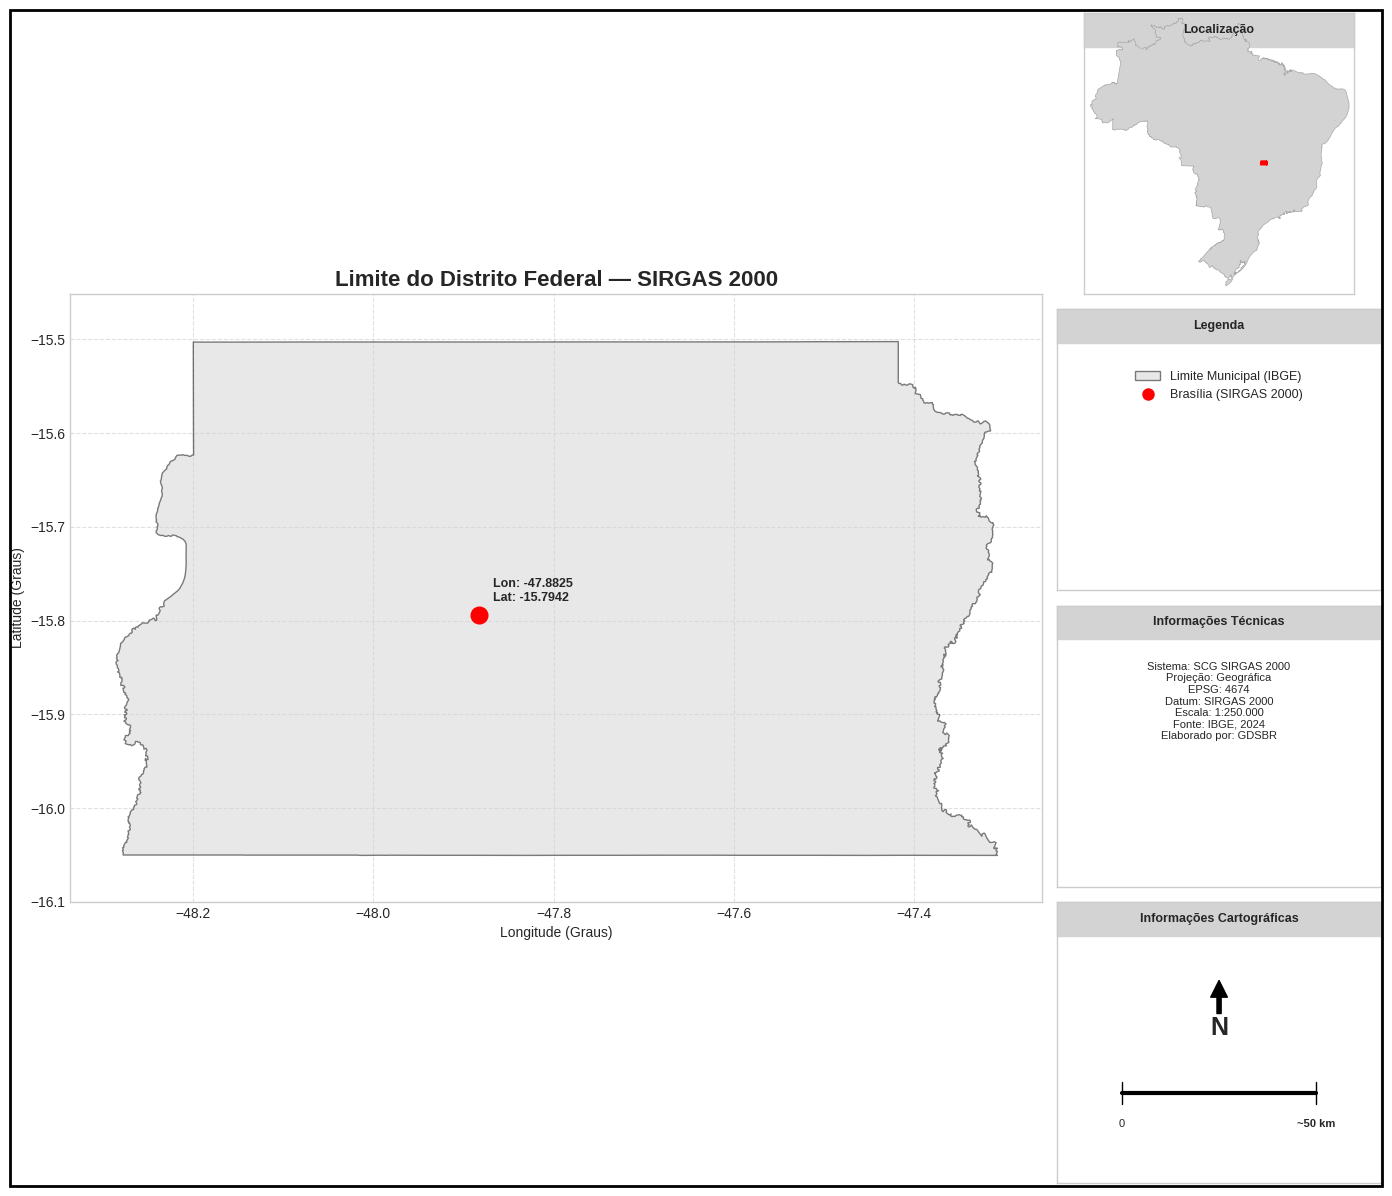

In [4]:
# =============================================================================
# MAPA BASE - Distrito Federal (Brasília)
# Projeto: GDS_BR | Geo Data Science Brasil
# Descrição: Script para gerar um mapa cartográfico do Distrito Federal com
#            dados oficiais do IBGE, usando o sistema SIRGAS 2000 (EPSG:4674).
#
# LAYOUT DOS PAINÉIS:
#  ┌──────────────────────┬──────────────────┐
#  │                      │  Localização     │
#  │                      ├──────────────────┤
#  │        MAPA          │  Legenda         │
#  │                      ├──────────────────┤
#  │                      │  Info. Técnicas  │
#  │                      ├──────────────────┤
#  │                      │  Info. Cartogr.  │
#  └──────────────────────┴──────────────────┘
# =============================================================================


# --- SEÇÃO 1: IMPORTAÇÃO DAS BIBLIOTECAS ---
import matplotlib.pyplot as plt                # Ferramenta principal para desenhar gráficos e mapas
from matplotlib.lines import Line2D            # Ferramenta para criar linhas personalizadas (usada na legenda)
from matplotlib.patches import Patch, Rectangle # 'Patch': áreas coloridas na legenda | 'Rectangle': retângulos
import geopandas as gpd                        # Ferramenta para trabalhar com dados geográficos (polígonos, malhas)
import requests                                # Ferramenta para fazer requisições à internet (baixar dados de APIs)
import io                                      # Ferramenta para tratar dados em memória como se fossem um arquivo
from shapely.geometry import Point             # Ferramenta para criar geometrias (Ponto, Linha, Polígono)
from pyproj import Transformer                 # Ferramenta para converter coordenadas entre diferentes projeções


# --- SEÇÃO 2: CONFIGURAÇÃO DO ESTILO VISUAL ---
# O 'try/except' tenta usar um estilo e, se falhar, usa uma alternativa.
try:
    plt.style.use('seaborn-v0_8-whitegrid')  # Estilo seaborn: fundo branco com grade cinza
except Exception:
    plt.style.use('ggplot')                  # Alternativa se o seaborn não estiver disponível


# --- SEÇÃO 3: DADOS GEOGRÁFICOS E PROJEÇÃO ---
# Define o ponto central de Brasília e converte para o sistema oficial: SIRGAS 2000 (EPSG:4674).

# Cria um conversor de coordenadas: de GPS (EPSG:4326) → SIRGAS 2000 Brasil (EPSG:4674)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:4674", always_xy=True)

lon, lat = -47.8825, -15.7942               # Longitude e latitude de Brasília (referência: GPS/Google Maps)
x, y = transformer.transform(lon, lat)       # Converte as coordenadas para o sistema SIRGAS 2000
ponto_brasilia = Point(x, y)                 # Cria o objeto geométrico "Ponto" com as coordenadas convertidas


# --- SEÇÃO 4: BUSCANDO DADOS GEOGRÁFICOS DO IBGE ---

# URL da API do IBGE: malha do Distrito Federal (ID 5300108), qualidade máxima
url_ibge = "https://servicodados.ibge.gov.br/api/v4/malhas/municipios/5300108?formato=application/vnd.geo+json&qualidade=maxima"
print("Buscando malha do Distrito Federal no IBGE...")
response = requests.get(url_ibge)                            # Faz o download dos dados geográficos
gdf_municipio = gpd.read_file(io.BytesIO(response.content)) # Lê os dados e cria um GeoDataFrame
gdf_municipio = gdf_municipio.to_crs("EPSG:4674")           # Converte para SIRGAS 2000

# URL da API do IBGE: contorno do Brasil inteiro (para o painel de Localização)
url_brasil = "https://servicodados.ibge.gov.br/api/v4/malhas/paises/BR?formato=application/vnd.geo+json&resolucao=2"
print("Buscando contorno do Brasil no IBGE...")
response_brasil = requests.get(url_brasil)                               # Faz o download do contorno do Brasil
gdf_brasil = gpd.read_file(io.BytesIO(response_brasil.content))         # Cria GeoDataFrame com o polígono do Brasil
gdf_brasil = gdf_brasil.set_crs("EPSG:4326", allow_override=True)       # Define o CRS (sistema de coordenadas) como geográfico
gdf_municipio_geo = gdf_municipio.to_crs("EPSG:4326")                   # Versão do DF em graus (para sobrepor no mapa de localização)


# --- SEÇÃO 5: DEFINIÇÃO DO LAYOUT DO MAPA (MOSAICO) ---
# O 'mapa' ocupa toda a coluna esquerda (4 linhas).
# A coluna direita tem 4 painéis: Localização, Legenda, Info. Técnicas e Info. Cartográficas.

layout = [
    ['mapa', 'localizacao'],   # Linha 1: mapa à esquerda | localização à direita
    ['mapa', 'legenda'],       # Linha 2: mapa continua  | legenda à direita
    ['mapa', 'info_tecnica'],  # Linha 3: mapa continua  | informações técnicas à direita
    ['mapa', 'info_carto'],    # Linha 4: mapa continua  | informações cartográficas à direita
]

# Cria a figura e os eixos de acordo com o layout
# figsize=(14, 12): largura 14", altura 12" | width_ratios=[3,1]: mapa 3x mais largo
# height_ratios=[1,1,1,1]: os 4 painéis direitos têm alturas iguais
fig, axs = plt.subplot_mosaic(
    layout,
    figsize=(14, 12),
    width_ratios=[3, 1],
    height_ratios=[1, 1, 1, 1]
)

ax_mapa        = axs['mapa']          # Atalho para o painel principal do mapa
ax_localizacao = axs['localizacao']   # Atalho para o painel de localização
ax_legenda     = axs['legenda']       # Atalho para o painel de legenda
ax_info_tec    = axs['info_tecnica']  # Atalho para o painel de informações técnicas
ax_info_carto  = axs['info_carto']    # Atalho para o painel de informações cartográficas


# =========================================================================
# --- SEÇÃO 6: PAINEL PRINCIPAL — MAPA ---
# =========================================================================

# Desenha a malha municipal (polígono do DF) no eixo do mapa
gdf_municipio.plot(ax=ax_mapa, color='lightgrey', edgecolor='black', alpha=0.5, label='Distrito Federal')

# Desenha o ponto de Brasília como marcador circular vermelho
ax_mapa.plot(
    ponto_brasilia.x,               # Coordenada X (longitude em SIRGAS 2000)
    ponto_brasilia.y,               # Coordenada Y (latitude em SIRGAS 2000)
    marker='o',                     # Formato do marcador: círculo
    color='red',                    # Cor: vermelho
    markersize=12,                  # Tamanho do marcador
    linestyle='None',               # Sem linha entre marcadores
    label='Brasília (SIRGAS 2000)'  # Rótulo para a legenda
)

# Adiciona uma anotação de texto com as coordenadas ao lado do ponto
ax_mapa.annotate(
    f'Lon: {ponto_brasilia.x:.4f}\nLat: {ponto_brasilia.y:.4f}',  # Texto com 4 casas decimais
    (ponto_brasilia.x, ponto_brasilia.y),                           # Posição da seta (onde aponta)
    xytext=(10, 10),                # Deslocamento do texto (10px para direita e para cima)
    textcoords='offset points',     # O deslocamento é em pontos (px)
    fontsize=9,
    fontweight='bold'
)

# Ajusta o zoom do mapa para enquadrar o DF com uma margem de 0.05 graus
minx, miny, maxx, maxy = gdf_municipio.total_bounds  # Limites geográficos (bounding box) da malha
ax_mapa.set_xlim(minx - 0.05, maxx + 0.05)           # Limite horizontal com margem
ax_mapa.set_ylim(miny - 0.05, maxy + 0.05)           # Limite vertical com margem

ax_mapa.set_title('Limite do Distrito Federal — SIRGAS 2000', fontsize=16, fontweight='bold')
ax_mapa.set_xlabel('Longitude (Graus)')    # Rótulo do eixo X
ax_mapa.set_ylabel('Latitude (Graus)')     # Rótulo do eixo Y
ax_mapa.grid(True, linestyle='--', alpha=0.6)  # Grade tracejada com 60% de opacidade


# =========================================================================
# --- SEÇÃO 7: PAINEL — LOCALIZAÇÃO ---
# Mostra um mapa miniatura do Brasil com o DF destacado em vermelho,
# para que o leitor saiba onde no país o mapa principal está localizado.
# =========================================================================

def _estilizar_painel(ax, titulo):
    """Função auxiliar: aplica bordas visíveis e um cabeçalho cinza ao painel."""
    for spine in ax.spines.values():    # Percorre os 4 lados do painel
        spine.set_visible(True)         # Torna o lado (borda) visível
        spine.set_linewidth(1)          # Espessura da borda: 1pt
    ax.set_xticks([])                   # Remove marcadores do eixo X
    ax.set_yticks([])                   # Remove marcadores do eixo Y
    # Retângulo cinza como cabeçalho no topo do painel
    ax.add_patch(Rectangle(
        (0, 0.88), 1, 0.12,            # Posição (canto esq. inferior do rect.) e dimensões
        transform=ax.transAxes,         # Coordenadas relativas ao tamanho do eixo (0 a 1)
        facecolor='lightgrey',          # Preenchimento: cinza claro
        edgecolor='lightgrey',          # Borda: mesma cor (invisível)
        lw=1,
        clip_on=False                   # Permite renderização além dos limites do eixo
    ))
    # Texto do título centralizado dentro do cabeçalho
    ax.text(0.5, 0.94, titulo,
            transform=ax.transAxes,
            fontsize=9, fontweight='bold',
            ha='center', va='center')

# Aplica o estilo padrão no painel de localização
_estilizar_painel(ax_localizacao, "Localização")

# Desenha o contorno do Brasil em cinza claro
gdf_brasil.plot(ax=ax_localizacao, color='lightgrey', edgecolor='darkgrey', linewidth=0.5)

# Destaca o Distrito Federal em vermelho no mapa de localização
gdf_municipio_geo.plot(ax=ax_localizacao, color='red', edgecolor='red')

ax_localizacao.set_xlim(-75, -34)   # Limita o eixo X para mostrar só o Brasil
ax_localizacao.set_ylim(-35, 6)     # Limita o eixo Y para mostrar só o Brasil


# =========================================================================
# --- SEÇÃO 8: PAINEL — LEGENDA ---
# =========================================================================

_estilizar_painel(ax_legenda, "Legenda")

# Cria manualmente os elementos visuais da legenda para ter controle total
legend_elements = [
    Patch(facecolor='lightgrey', edgecolor='black', alpha=0.5, label='Limite Municipal (IBGE)'),
    Line2D([0], [0], marker='o', color='w', label='Brasília (SIRGAS 2000)',
           markerfacecolor='red', markersize=10, linestyle='None')
]

# Posiciona a legenda dentro do painel, abaixo do cabeçalho
ax_legenda.legend(
    handles=legend_elements,          # Lista de elementos visuais
    loc='upper center',               # Ancora no centro superior
    bbox_to_anchor=(0.5, 0.82),      # Ajuste fino de posição (abaixo do header)
    fontsize=9,                       # Tamanho da fonte
    frameon=False                     # Sem caixa ao redor
)


# =========================================================================
# --- SEÇÃO 9: PAINEL — INFORMAÇÕES TÉCNICAS ---
# Contém os metadados técnicos (sistema de coordenadas, datum, projeção, etc.).
# =========================================================================

_estilizar_painel(ax_info_tec, "Informações Técnicas")

# Texto com os metadados técnicos do mapa
texto_tecnico = (
    "Sistema: SCG SIRGAS 2000\n"   # Sistema Geodésico de referência
    "Projeção: Geográfica\n"
    "EPSG: 4674\n"
    "Datum: SIRGAS 2000\n"
    "Escala: 1:250.000\n"
    "Fonte: IBGE, 2024\n"
    "Elaborado por: GDSBR"
)
# Exibe o texto de informações técnicas abaixo do cabeçalho
ax_info_tec.text(
    0.5, 0.80,                      # Posição: 50% horizontal, 80% vertical
    texto_tecnico,
    transform=ax_info_tec.transAxes,
    fontsize=8,                     # Fonte pequena para caber no painel
    ha='center', va='top'          # Alinhamento: centro horizontal, topo vertical
)


# =========================================================================
# --- SEÇÃO 10: PAINEL — INFORMAÇÕES CARTOGRÁFICAS ---
# Contém a seta de Norte e a escala gráfica.
# =========================================================================

_estilizar_painel(ax_info_carto, "Informações Cartográficas")

# --- Seta do Norte ---
# annotate() com seta: o texto 'N' fica em xytext e a seta aponta para xy
ax_info_carto.annotate(
    'N',                                          # Texto "N" (Norte)
    xy=(0.5, 0.72),                              # Ponta da seta (onde aponta)
    xytext=(0.5, 0.55),                          # Base da seta (onde fica o "N")
    arrowprops=dict(facecolor='black', width=3, headwidth=12),  # Estilo da seta
    ha='center', va='center',
    fontsize=18, fontweight='bold',
    xycoords=ax_info_carto.transAxes             # Coordenadas relativas ao eixo
)

# --- Escala Gráfica ---
# Uma linha horizontal com marcadores nos extremos representa a escala
ax_info_carto.plot([0.2, 0.8], [0.32, 0.32], transform=ax_info_carto.transAxes, color='black', lw=3)  # Linha principal
ax_info_carto.plot([0.2, 0.2], [0.28, 0.36], transform=ax_info_carto.transAxes, color='black', lw=1)  # Marcador esquerdo
ax_info_carto.plot([0.8, 0.8], [0.28, 0.36], transform=ax_info_carto.transAxes, color='black', lw=1)  # Marcador direito
ax_info_carto.text(0.2, 0.20, "0",      transform=ax_info_carto.transAxes, ha='center', fontsize=8)                # Rótulo "0"
ax_info_carto.text(0.8, 0.20, "~50 km", transform=ax_info_carto.transAxes, ha='center', fontsize=8, fontweight='bold')  # Rótulo "~50km"


# =========================================================================
# --- SEÇÃO 11: FINALIZAÇÃO E EXPORTAÇÃO ---
# =========================================================================

plt.tight_layout()  # Ajusta automaticamente o espaçamento entre painéis para evitar sobreposições

# Adiciona moldura negra ao redor de toda a figura
fig.patches.extend([
    Rectangle(
        (0.01, 0.01), 0.98, 0.98,  # Margem de 1% em todos os lados
        fill=False,                  # Sem preenchimento (só o contorno)
        color='black',               # Cor da borda: preta
        lw=2,                        # Espessura: 2pt
        transform=fig.transFigure,   # Coordenadas relativas à figura inteira
        figure=fig                   # Associa o patch à figura
    )
])

plt.savefig('mapa_ibge_sirgas.png', dpi=150)          # Salva o mapa como PNG com 150 DPI de resolução
print("Mapa 'mapa_ibge_sirgas.png' gerado com sucesso!")  # Confirmação de sucesso no terminal
